## Environment Setup

In [1]:
!gdown --id "1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ"

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ
From (redirected): https://drive.google.com/uc?id=1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ&confirm=t&uuid=1ade07f5-14bd-4997-93bc-35484d9e4d70
To: /content/Divar.csv
100% 794M/794M [00:09<00:00, 84.3MB/s]


## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# setup dataset

In [3]:
DATA_PATH: str = "/content/Divar.csv"

## Data Loading

In [4]:
df_raw = pd.read_csv(DATA_PATH)

print(f"Shape: {df_raw.shape}")
df_raw.info()
df_raw.head()


/tmp/ipykernel_632/2287252603.py:1: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(DATA_PATH)


Shape: (1000000, 61)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 61 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Unnamed: 0                  1000000 non-null  int64  
 1   cat2_slug                   1000000 non-null  object 
 2   cat3_slug                   999999 non-null   object 
 3   city_slug                   999998 non-null   object 
 4   neighborhood_slug           437139 non-null   object 
 5   created_at_month            1000000 non-null  object 
 6   user_type                   288882 non-null   object 
 7   description                 1000000 non-null  object 
 8   title                       999946 non-null   object 
 9   rent_mode                   352994 non-null   object 
 10  rent_value                  351322 non-null   float64
 11  rent_to_single              19 non-null       object 
 12  rent_type                   103961 n

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Distribution of Selling Prices across Categories

To understand the price behavior and identify potential outliers across different property types, we filter the dataset to include only sales transactions (excluding rentals). The price range is constrained between $10^7$ (10 million) and $5 \times 10^{11}$ (500 billion) to capture valid structural listings.

Since real estate pricing spans several orders of magnitude, a **logarithmic scale** ($\log_{10}$) is applied to the y-axis ($price\_value$) to effectively normalize the visualization and compare the distributions side-by-side.

The boxplot below illustrates the distribution of these selling prices categorized by their specific sub-category (`cat3_slug`).

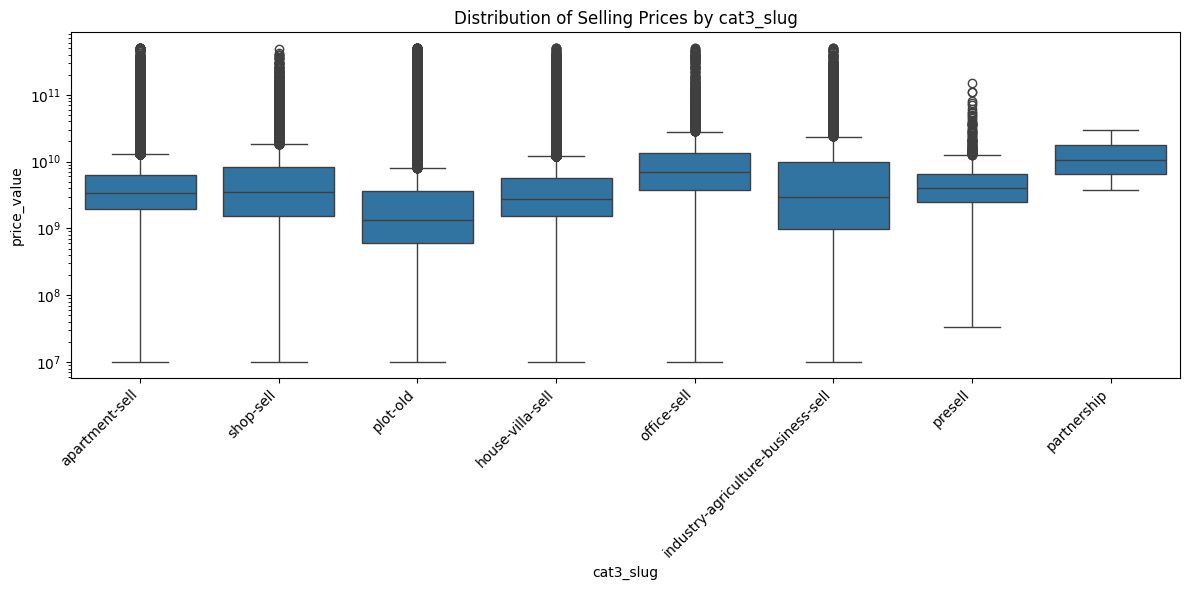

In [5]:
df_sell_preview = df_raw[~df_raw["cat3_slug"].str.contains("rent", na=True)]
price_band_preview = df_sell_preview[
    (df_sell_preview["price_value"] >= 10_000_000)
    & (df_sell_preview["price_value"] <= 500_000_000_000)
]

plt.figure(figsize=(12, 6))
sns.boxplot(data=price_band_preview, x="cat3_slug", y="price_value")
plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Selling Prices by cat3_slug")
plt.tight_layout()
plt.show()


### Key Insights from the Boxplot Analysis

* **Logarithmic Distribution & Variance:** The usage of a log scale reveals that while the median prices for most categories hover around the $10^9$ to $10^{10}$ range, the full spread spans from $10^7$ up to $5 \times 10^{11}$.
* **Commercial Premium:** The `office-sell` and `partnership` categories exhibit the highest median values, indicating a significant premium for commercial and collaborative development spaces compared to residential properties.
* **Heavy Right-Skew (Outliers):** Categories like `apartment-sell`, `shop-sell`, `plot-old`, and `house-villa-sell` show a massive, dense cluster of upper outliers (represented by the solid black columns of circles stretching toward $5 \times 10^{11}$). This suggests that while standard units follow a predictable pricing tier, unique luxury properties or massive commercial plots heavily skew the top end of the market.
* **Data Scarcity/Cleanliness:** The `partnership` category stands out due to its complete lack of plotted outliers, suggesting either a lower sample size in the dataset or a more tightly controlled, uniform pricing structure for these specific agreements.